# Secondary outcome leave missing values

In [1]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

test_data_path = os.getenv('NATIONAL_VAL_SECONDARY_OUTCOME')
test = pd.read_csv(test_data_path)
test = test.drop(columns=['Studio', 'ESRD', 'Creat1', 'esrd_upper', 'esrd_lower'])
test.shape

(358, 17)

In [2]:
import joblib

rsf = joblib.load('rsf.joblib')

In [3]:
features = ['Eta1', 'Epi1', 'Hb1', 
            'Prot1', 'Colesterolo1', 'P1', 
            'Ca1', 'Sesso', 'ckd_cause_glom_dis', 
            'Death_preHD', 'fu_morte_1']
test = test[features]

test.rename(columns={'Epi1': 'EGFR',
                     'Prot1': 'URIN_PROT',
                     'Eta1': 'AGE',
                     'P1': 'PHOSPHORUS',
                     'Ca1': 'CALCIUM',
                     'Hb1': 'HB',
                     'Colesterolo1': 'CHOLESTEROL',
                     'Sesso': 'MALE',
                     'ckd_cause_glom_dis': 'GLOM_DISEASE',
                     'fu_morte_1': 'time_to_mortality',
                     'Death_preHD': 'mortality'}, inplace=True)
print(round(test['time_to_mortality'].describe(), 1))
print((test['mortality'] == 1).sum())
print(round(((test['mortality'] == 1).sum() / test.shape[0]) * 100, 1))

count    358.0
mean      53.3
std       32.8
min        3.3
25%       24.9
50%       51.4
75%       74.9
max      162.5
Name: time_to_mortality, dtype: float64
61
17.0


In [4]:
from sksurv.ensemble import RandomSurvivalForest
from lifelines.utils import concordance_index

predicted_test = rsf.predict(test.drop(columns=['mortality', 'time_to_mortality']))
c_index_test = round(concordance_index(test['time_to_mortality'], -predicted_test, test['mortality']), 3)
print(f'Concordance index for mortality prediction national validation: {c_index_test}')

Concordance index for mortality prediction national validation: 0.749


In [5]:
intl_val_data_path = os.getenv('INTL_VAL')
intl_val_extra_data_path = os.getenv('INTL_VAL_EXTRA_DATA')
test_intl = pd.read_csv(intl_val_data_path)
test_intl_extra = pd.read_csv(intl_val_extra_data_path)
test_intl = test_intl.merge(test_intl_extra, on='ID_UMCG')
test_intl['MALE'] = (test_intl['GESLACHT'] == 2).astype(int)
test_intl.rename(columns={'Epi1': 'EGFR',
                          'Proteinurieurine': 'URIN_PROT',
                          'bmi': 'BMI',
                          'age': 'AGE',
                          'Fosfaat': 'PHOSPHORUS',
                          'Calciumbloed': 'CALCIUM',
                          'Hbmmolperliter': 'HB',
                          'totaalcholesterol': 'CHOLESTEROL'}, inplace=True)
test_intl = test_intl[test.columns]

In [6]:
# Convert features into the correct units
# https://www.ukkidney.org/sites/renal.org/files/Appendix-I_0.pdf
test_intl['PHOSPHORUS'] = test_intl['PHOSPHORUS'] * 3.1
test_intl['CALCIUM'] = test_intl['CALCIUM'] * 4
test_intl['CHOLESTEROL'] = test_intl['CHOLESTEROL'] * 38.6
# https://www.unitsconverters.com/en/Mmol/L-To-G/Dl/Utu-6013-6012
test_intl['HB'] = test_intl['HB'] * 1.6113

In [7]:
predicted_test_intl = rsf.predict(test_intl.drop(columns=['mortality', 'time_to_mortality']))

In [8]:
c_index_test = round(concordance_index(test_intl['time_to_mortality'], -predicted_test_intl, test_intl['mortality']), 3)
print(f'Concordance index for mortality prediction national validation: {c_index_test}')

Concordance index for mortality prediction national validation: 0.761


In [9]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

sfs_nat = rsf.predict_survival_function(test.drop(columns=['mortality', 'time_to_mortality']), return_array = True)
sfs_nat_mean = sfs_nat.mean(axis=0)

km_nat = KaplanMeierFitter()
km_nat.fit(durations=test['time_to_mortality'], event_observed=test['mortality'])

sfs_intl = rsf.predict_survival_function(test_intl.drop(columns=['mortality', 'time_to_mortality']), return_array = True)
sfs_intl_mean = sfs_intl.mean(axis=0)

km_intl = KaplanMeierFitter()
km_intl.fit(durations=test_intl['time_to_mortality'], event_observed=test_intl['mortality'])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 368 total observations, 285 right-censored observations>

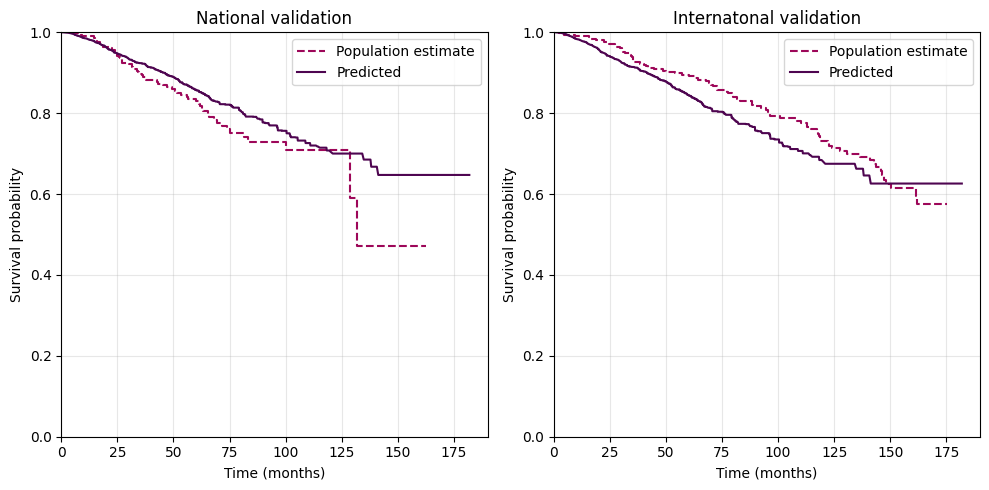

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharex=True)

km_nat.plot_survival_function(
    ci_show=False,
    label="Population estimate",
    color='xkcd:dark fuchsia',
    linestyle='--',
    ax=axes[0]
)
axes[0].plot(rsf.unique_times_, sfs_intl_mean,
             label='Predicted', color='xkcd:plum purple')
axes[0].set_xlim(0,190)
axes[0].set_ylim(0,1)
axes[0].set_xlabel("Time (months)")
axes[0].set_ylabel("Survival probability")
axes[0].set_title("National validation")
axes[0].legend()
axes[0].grid(alpha=0.3)

km_intl.plot_survival_function(
    ci_show=False,
    label="Population estimate",
    color='xkcd:dark fuchsia',
    linestyle='--',
    ax=axes[1]
)
axes[1].plot(rsf.unique_times_, sfs_nat_mean,
             label='Predicted', color='xkcd:plum purple')
axes[1].set_xlim(0,190)
axes[1].set_ylim(0,1)
axes[1].set_xlabel("Time (months)")
axes[1].set_ylabel("Survival probability")
axes[1].set_title("Internatonal validation")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/supplemental_figure_12.pdf")
plt.show()